In [4]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from helpers import load, feature_names, swap_sides

In [12]:
organic, farm = load()
names = feature_names()
print(organic.shape, farm.shape, len(names))

(2209, 239) (6000, 241) 228


In [15]:
organic[["kind", "round", "label", "log_kill_time_ratio", "log_heur_power_ratio"]].head(10)

,kind,round,label,log_kill_time_ratio,log_heur_power_ratio
0,bot,1,1,2.893512,1.446756
1,bot,2,1,1.214886,0.607443
2,bot,3,0,0.377023,0.142608
3,bot,4,0,0.506473,0.253236
4,bot,5,0,-0.340599,-0.167919
5,bot,6,0,0.710703,0.321899
6,bot,1,1,1.782607,0.942106
7,bot,2,0,-1.338189,-0.652474
8,bot,3,0,-2.759152,-1.253914
9,bot,4,0,-2.756772,-1.345338


In [16]:
organic.groupby("kind").label.agg(["count", "mean"])

,count,mean
kind,,
bot,1451,0.441764
run,758,0.637203


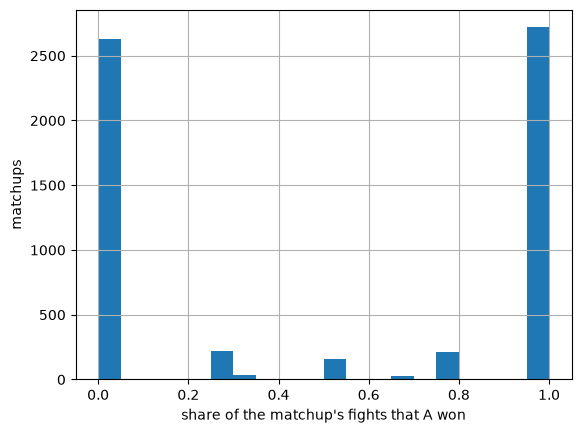

In [17]:
farm.label.hist(bins=20)
plt.xlabel("share of the matchup's fights that A won")
plt.ylabel("matchups")
plt.show()

In [18]:
def win_rate_by(df, column, bins=10):
    """Sort the fights by `column`, cut them into `bins` equal-sized groups,
    and return each group's average `column` value and win rate."""
    groups = pd.qcut(df[column], q=bins, duplicates="drop")
    return df.groupby(groups, observed=True).agg(
        x=(column, "mean"),
        win_rate=("label", "mean"),
        fights=("label", "size"),
    )

win_rate_by(organic, "log_kill_time_ratio")

,x,win_rate,fights
log_kill_time_ratio,,,
"(-6.148000000000001, -2.198]",-3.130949,0.235294,221
"(-2.198, -1.393]",-1.747918,0.176471,221
"(-1.393, -0.819]",-1.091865,0.230769,221
"(-0.819, -0.36]",-0.581555,0.248869,221
"(-0.36, 0.0535]",-0.157042,0.425339,221
"(0.0535, 0.48]",0.258563,0.600000,220
"(0.48, 1.145]",0.776326,0.751131,221
"(1.145, 1.895]",1.540096,0.809955,221
"(1.895, 2.592]",2.220560,0.800905,221


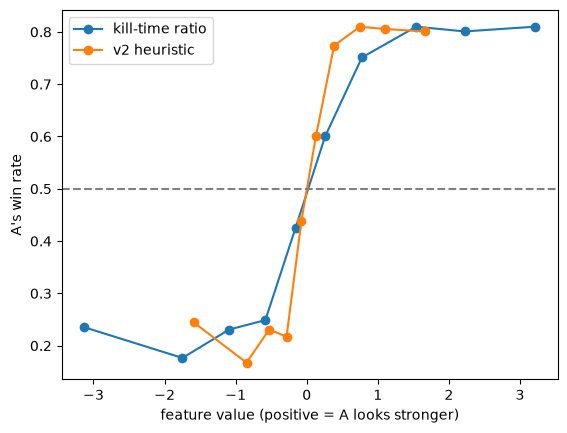

In [19]:
ax = win_rate_by(organic, "log_kill_time_ratio").plot(x="x", y="win_rate", marker="o", label="kill-time ratio")
win_rate_by(organic, "log_heur_power_ratio").plot(x="x", y="win_rate", marker="o", label="v2 heuristic", ax=ax)
ax.axhline(0.5, color="grey", linestyle="--")
ax.set_xlabel("feature value (positive = A looks stronger)")
ax.set_ylabel("A's win rate")
plt.show()

In [20]:
def talent_effect(df, talent_id):
    has = df[f"a_t_{talent_id}"] == 1
    return pd.Series({
        "fights_with": has.sum(),
        "win_rate_with": df.label[has].mean(),
        "fights_without": (~has).sum(),
        "win_rate_without": df.label[~has].mean(),
    })

pd.DataFrame({talent: talent_effect(organic, talent) for talent in [15, 401, 38]}).T

,fights_with,win_rate_with,fights_without,win_rate_without
15,86.0,0.441860,2123.0,0.511540
401,45.0,0.422222,2164.0,0.510628
38,79.0,0.670886,2130.0,0.502817


In [21]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Hold out 20% of CHARACTERS as the final test set.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
trainval_idx, test_idx = next(gss.split(organic, groups=organic["aOriginalPlayerId"]))
trainval, test = organic.iloc[trainval_idx], organic.iloc[test_idx]

# 2. Split the rest into train and validation, the same way.
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=1)
train_idx, val_idx = next(gss.split(trainval, groups=trainval["aOriginalPlayerId"]))
train, val = trainval.iloc[train_idx], trainval.iloc[val_idx]

print(len(train), len(val), len(test))
print("characters in both train and test:", len(set(train.aOriginalPlayerId) & set(test.aOriginalPlayerId)))

1287 477 445
characters in both train and test: 0


In [22]:
ordered = organic.sort_values("createdAt")
future = ordered.iloc[int(len(ordered) * 0.85):]   # the newest 15% of fights
print(len(future), "fights since", future.createdAt.min())

332 fights since 2026-09-23 17:45:29.625000+00:00


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

def score(name, y, p):
    p = np.clip(p, 1e-6, 1 - 1e-6)   # log loss is infinite at exactly 0 or 1
    return {"model": name,
            "log_loss": log_loss(y, p, labels=[0, 1]),
            "auc": roc_auc_score(y, p),
            "brier": brier_score_loss(y, p)}

results = []

# Baseline 0: ignore the fight entirely, always predict the training win rate.
results.append(score("0: always the average", val.label, np.full(len(val), train.label.mean())))

# Baselines 1 and 2: a logistic regression on ONE number each.
for column in ["log_heur_power_ratio", "log_kill_time_ratio"]:
    lr = LogisticRegression().fit(train[[column]], train.label)
    results.append(score(f"LR on {column}", val.label, lr.predict_proba(val[[column]])[:, 1]))

pd.DataFrame(results).round(4)

,model,log_loss,auc,brier
0,0: always the average,0.6932,0.5000,0.2500
1,LR on log_heur_power_ratio,0.5973,0.7686,0.2022
2,LR on log_kill_time_ratio,0.5968,0.7677,0.2021


In [24]:
human_val = val[val.kind == "run"]
lr = LogisticRegression().fit(train[["log_heur_power_ratio"]], train.label)
score("LR heur, humans only", human_val.label, lr.predict_proba(human_val[["log_heur_power_ratio"]])[:, 1])

{'model': 'LR heur, humans only',
 'log_loss': 0.5953978932776871,
 'auc': 0.7860049469400783,
 'brier': 0.20173329160719503}